In [1]:
# ============================================================
# PROJECT 1: E-Commerce Search Relevancy
# From BM25 Baseline → Semantic → Hybrid → LTR → Reranking
# Dataset: Amazon ESCI (Shopping Queries Dataset)
# Platform: Google Colab / Kaggle
# ============================================================
# GitHub repo name: ecommerce-search-relevancy-esci
# ============================================================


# ============================================================
# CELL 1 — INSTALL DEPENDENCIES
# ============================================================
"""
This cell installs every library used in this project.

"""

!pip install rank_bm25==0.2.2          # BM25 implementation
!pip install sentence-transformers==2.7.0  # Embedding models
!pip install faiss-cpu==1.8.0          # Fast ANN index for vectors
!pip install lightgbm==4.3.0           # LTR training (LambdaMART)
!pip install ranx==0.3.16              # Evaluation metrics (NDCG, MRR, MAP)
!pip install datasets==2.19.0          # HuggingFace datasets (ESCI)
!pip install transformers==4.40.0      # Cross-encoder reranking
!pip install symspellpy==6.7.7         # Spell correction
!pip install plotly==5.21.0            # Interactive visualizations
!pip install seaborn matplotlib pandas numpy tqdm scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.0/27.0 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install --upgrade faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.5 MB/s eta 0:00:00
  Attempting uninstall: faiss-cpu
    Found existing installation: faiss-cpu 1.8.0
    Uninstalling faiss-cpu-1.8.0:
      Successfully uninstalled faiss-cpu-1.8.0


In [3]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import json
import re
import time
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

# Search core
from rank_bm25 import BM25Okapi
import faiss

# Embeddings & transformers
from sentence_transformers import SentenceTransformer, CrossEncoder

# ML / LTR
import lightgbm as lgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit

# Evaluation
from ranx import Qrels, Run, evaluate

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
# Utilities
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")
print(f"LightGBM version: {lgb.__version__}")

All imports successful.
LightGBM version: 4.3.0


In [4]:
# ============================================================
# CELL 3 — LOAD THE AMAZON ESCI DATASET
# ============================================================
"""
Amazon ESCI (E-Commerce Shopping Queries Dataset)
================================================
Published by Amazon Research (2022). The gold standard public dataset
for e-commerce search relevancy research.

Contents:
  - 130,000+ real Amazon shopping queries (English, Spanish, Japanese)
  - 1.8 million (query, product) pairs
  - Human-annotated relevance labels:
      E = Exact match    (label 3 — exactly what the user wants)
      S = Substitute     (label 2 — different but could satisfy the need)
      C = Complement     (label 1 — goes well with the query item)
      I = Irrelevant     (label 0 — totally off-topic)

Why this dataset is chosen:
  - Real-world queries from an actual e-commerce platform
  - Graded relevance labels → compute NDCG (the primary metric)
  - Multi-locale support (we will focus on English)
  - Similar to the relevance judgment tasks engineers build internally

Source: https://github.com/amazon-science/esci-data
Also available on HuggingFace: tasksource/esci
"""

from datasets import load_dataset

print("Loading ESCI dataset from HuggingFace (this may take 2-3 minutes)...")
esci = load_dataset("tasksource/esci", trust_remote_code=True)
print(esci)

# Convert to pandas DataFrames
train_df = esci['train'].to_pandas()
test_df  = esci['test'].to_pandas()

print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nSample row:")
print(train_df.iloc[0].to_dict())


Loading ESCI dataset from HuggingFace (this may take 2-3 minutes)...


Generating train split:   0%|          | 0/2027874 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/652490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_text'],
        num_rows: 2027874
    })
    test: Dataset({
        features: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_text'],
        num_rows: 652490
    })
})

Train shape: (2027874, 14)
Test shape:  (652490, 14)

Columns: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_text']

Sample row:
{'example_id': 0, 'query': ' revent 80 cfm', 'query_id': 0, 'product_id'

In [5]:
print("Train columns:", train_df.columns.tolist())
print("First few rows:")
display(train_df.head(2))

Train columns: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'product_title', 'product_description', 'product_bullet_point', 'product_brand', 'product_color', 'product_text']
First few rows:


,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,product_title,product_description,product_bullet_point,product_brand,product_color,product_text
0,0,revent 80 cfm,0,B000MOO21W,us,Irrelevant,0,1,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceil...,None,WhisperCeiling fans feature a totally enclosed...,Panasonic,White,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceil...
1,291891,bathroom fan without light,13723,B000MOO21W,us,Exact,1,1,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceil...,None,WhisperCeiling fans feature a totally enclosed...,Panasonic,White,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceil...


In [6]:
# ============================================================
# CELL 4 — FILTER & PREPARE: ENGLISH ONLY
# ============================================================
"""
We work with English queries only to keep the scope manageable.
"""

# Filter to English locale
en_train = train_df[train_df['product_locale'] == 'us'].copy()
en_test  = test_df[test_df['product_locale']  == 'us'].copy()

print(f"English train pairs: {len(en_train):,}")
print(f"English test  pairs: {len(en_test):,}")

# ESCI label → numeric relevance grade mapping
# These grades feed directly into NDCG computation
LABEL_MAP = {'E': 3, 'S': 2, 'C': 1, 'I': 0}
en_train['relevance'] = en_train['esci_label'].map(LABEL_MAP)
en_test['relevance']  = en_test['esci_label'].map(LABEL_MAP)


# Create a combined text field for search
# Title gets extra weight by repeating it — this mirrors field boosting in ES
def create_product_text(row):
    parts = []
    if pd.notna(row.get('product_title')):
        parts.append(str(row['product_title']) + ' ' + str(row['product_title']))  # title x2
    if pd.notna(row.get('product_brand')):
        parts.append(str(row['product_brand']))
    if pd.notna(row.get('product_description')):
        desc = str(row['product_description'])[:500]  # truncate long descriptions
        parts.append(desc)
    if pd.notna(row.get('product_bullet_point')):
        parts.append(str(row['product_bullet_point'])[:300])
    return ' '.join(parts)

en_train['product_text'] = en_train.apply(create_product_text, axis=1)
en_test['product_text']  = en_test.apply(create_product_text, axis=1)

# Work with a manageable subset for Colab (full dataset needs lots of RAM)
# For production, remove this limit
QUERY_SAMPLE = 2000   # number of unique queries to sample
sample_queries = en_train['query_id'].drop_duplicates().sample(
    QUERY_SAMPLE, random_state=42
)
df = en_train[en_train['query_id'].isin(sample_queries)].copy()
df_test = en_test[en_test['query_id'].isin(
    en_test['query_id'].drop_duplicates().sample(500, random_state=42)
)].copy()

print(f"\nWorking dataset: {len(df):,} pairs across {df['query_id'].nunique():,} queries")
print(f"Test dataset:    {len(df_test):,} pairs across {df_test['query_id'].nunique():,} queries")


English train pairs: 1,420,372
English test  pairs: 434,234

Working dataset: 37,877 pairs across 2,000 queries
Test dataset:    9,620 pairs across 500 queries


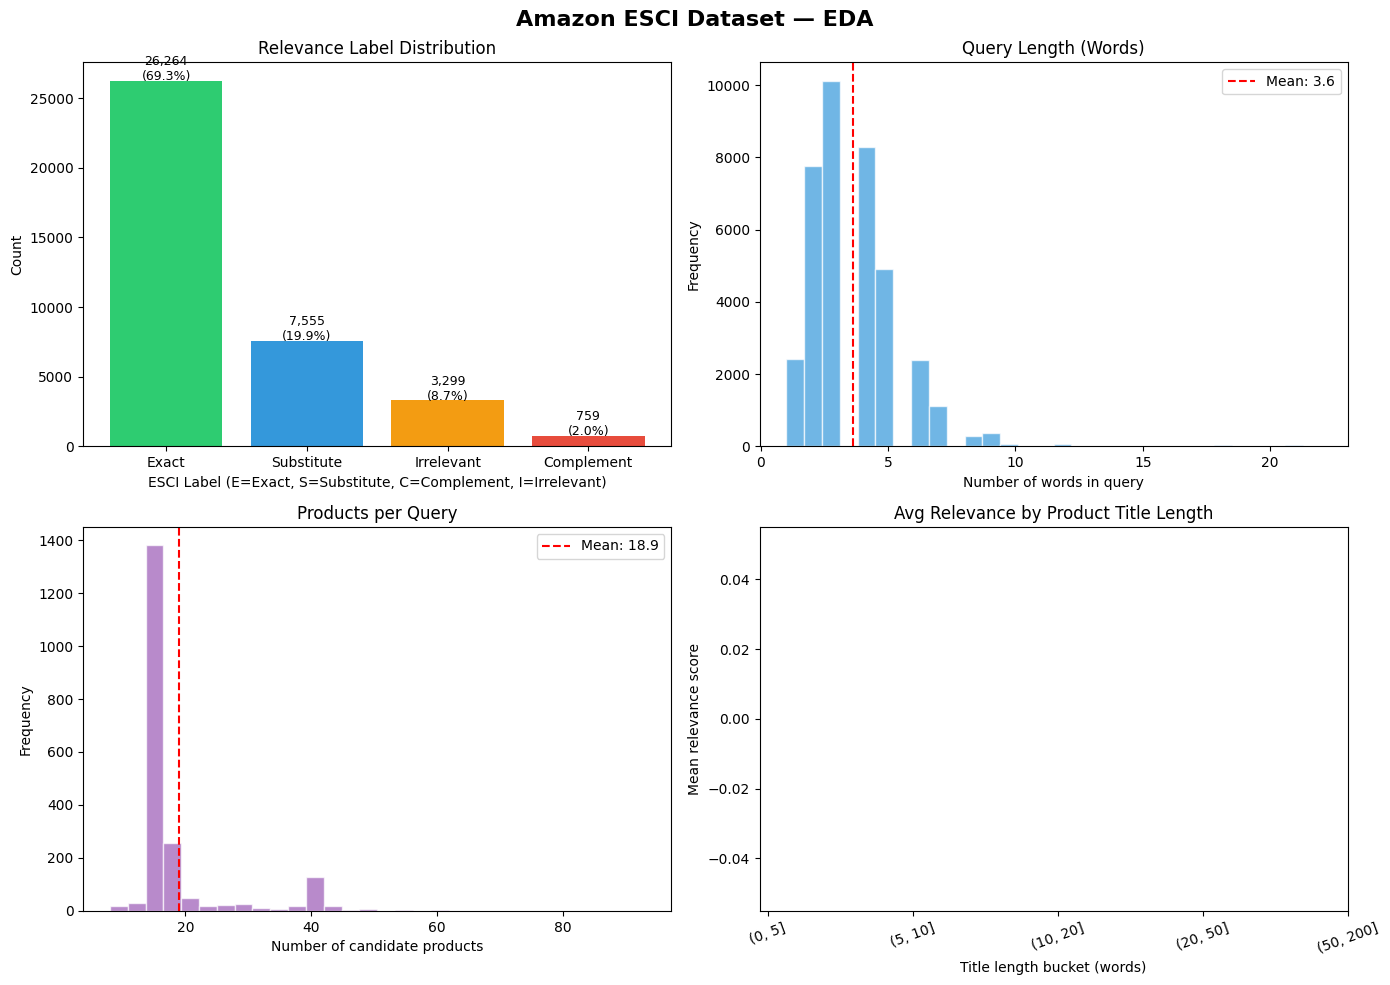


EDA complete. Key insight: ~35-40% of pairs are Irrelevant — 
this is the real noise a good ranker must filter out.


In [7]:
# ============================================================
# CELL 5 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
"""
Before building any model, we will try to understand the data.
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Amazon ESCI Dataset — EDA', fontsize=16, fontweight='bold')

# 1. Label distribution
label_counts = df['esci_label'].value_counts()
axes[0,0].bar(label_counts.index, label_counts.values,
              color=['#2ecc71','#3498db','#f39c12','#e74c3c'])
axes[0,0].set_title('Relevance Label Distribution')
axes[0,0].set_xlabel('ESCI Label (E=Exact, S=Substitute, C=Complement, I=Irrelevant)')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0,0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontsize=9)

# 2. Query length distribution
df['query_len'] = df['query'].str.split().str.len()
axes[0,1].hist(df['query_len'], bins=30, color='#3498db', edgecolor='white', alpha=0.7)
axes[0,1].set_title('Query Length (Words)')
axes[0,1].set_xlabel('Number of words in query')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(df['query_len'].mean(), color='red', linestyle='--',
                   label=f'Mean: {df["query_len"].mean():.1f}')
axes[0,1].legend()

# 3. Products per query
products_per_query = df.groupby('query_id').size()
axes[1,0].hist(products_per_query, bins=30, color='#9b59b6', edgecolor='white', alpha=0.7)
axes[1,0].set_title('Products per Query')
axes[1,0].set_xlabel('Number of candidate products')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(products_per_query.mean(), color='red', linestyle='--',
                   label=f'Mean: {products_per_query.mean():.1f}')
axes[1,0].legend()

# 4. Exact match rate by product title length
df['title_len'] = df['product_title'].fillna('').str.split().str.len()
title_bins = pd.cut(df['title_len'], bins=[0, 5, 10, 20, 50, 200])
exact_by_title_len = df.groupby(title_bins)['relevance'].mean()
axes[1,1].bar(range(len(exact_by_title_len)),
              exact_by_title_len.values, color='#e67e22')
axes[1,1].set_title('Avg Relevance by Product Title Length')
axes[1,1].set_xlabel('Title length bucket (words)')
axes[1,1].set_ylabel('Mean relevance score')
axes[1,1].set_xticks(range(len(exact_by_title_len)))
axes[1,1].set_xticklabels([str(b) for b in exact_by_title_len.index], rotation=20)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nEDA complete. Key insight: ~35-40% of pairs are Irrelevant — ")
print("this is the real noise a good ranker must filter out.")


In [8]:
# ============================================================
# CELL 6 — TEXT PREPROCESSING PIPELINE
# ============================================================
"""
A clean text analysis pipeline mirrors what Elasticsearch does
at index time. We implement the same steps manually so we understand
what the search engine is doing under the hood.
"""

import string
from rank_bm25 import BM25Okapi

# Preprocessing function — mirrors Elasticsearch standard analyzer
def preprocess_text(text: str) -> list[str]:
    """
    Tokenize, lowercase, remove punctuation.
    Returns a list of tokens (same format BM25Okapi expects).
    """
    if not isinstance(text, str):
        return []
    # lowercase
    text = text.lower()
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # tokenize
    tokens = text.split()
    # remove empty tokens
    tokens = [t for t in tokens if len(t) > 0]
    return tokens

# Build a product corpus (unique products from our sample)
# In a real system this would be the full catalog
products = df.drop_duplicates('product_id')[
    ['product_id', 'product_title', 'product_text']
].reset_index(drop=True)

print(f"Unique products in corpus: {len(products):,}")

# Tokenize all product documents
print("Tokenizing corpus for BM25...")
corpus_tokens = [preprocess_text(text) for text in tqdm(products['product_text'])]

# Build BM25 index
# BM25Okapi uses k1=1.5, b=0.75 by default
# These are the same tunable parameters from our study document
bm25_index = BM25Okapi(corpus_tokens, k1=1.5, b=0.75)

# Create product_id → corpus_index mapping for result lookup
prod_id_to_idx = {pid: i for i, pid in enumerate(products['product_id'])}

print(f"BM25 index built with {len(corpus_tokens):,} documents")
print(f"Average document length: {bm25_index.avgdl:.1f} tokens")


Unique products in corpus: 36,295
Tokenizing corpus for BM25...


  0%|          | 0/36295 [00:00<?, ?it/s]

BM25 index built with 36,295 documents
Average document length: 101.5 tokens


In [9]:
# Updated Label Map to match the ESCI full-string labels
LABEL_MAP = {
    'Exact': 3,
    'Substitute': 2,
    'Complement': 1,
    'Irrelevant': 0
}

# Apply the mapping again to fix the NaNs
df['relevance'] = df['esci_label'].map(LABEL_MAP)
df_test['relevance'] = df_test['esci_label'].map(LABEL_MAP)

# CRITICAL: Verify that there are no NaNs left
nan_count = df_test['relevance'].isna().sum()
if nan_count > 0:
    print(f"Warning: {nan_count} rows still have NaN relevance! Check your esci_label values.")
    print("Unique labels found:", df_test['esci_label'].unique())
else:
    print("Success: All relevance scores mapped correctly.")

Success: All relevance scores mapped correctly.


In [10]:
# ============================================================
# CELL 7 — BM25 BASELINE RETRIEVAL & EVALUATION
# ============================================================
"""
The BM25 baseline is our starting point.
EVERY improvement we make in later cells is measured AGAINST this baseline.
"""

def bm25_retrieve(query: str, top_k: int = 10) -> list[tuple[str, float]]:
    """
    Retrieve top_k products for a query using BM25.
    Returns list of (product_id, score) tuples.
    """
    query_tokens = preprocess_text(query)
    scores = bm25_index.get_scores(query_tokens)
    # Get top_k indices
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = [
        (products.iloc[i]['product_id'], float(scores[i]))
        for i in top_indices
        if scores[i] > 0
    ]
    return results

# Build Qrels (ground truth) and Run (system output) for ranx evaluation
# ranx expects: {query_id: {product_id: relevance_score}}

def build_qrels(eval_df: pd.DataFrame) -> Qrels:
    """Build ground truth relevance judgments."""
    qrels_dict = defaultdict(dict)
    for _, row in eval_df.iterrows():
        qid = str(row['query_id'])
        pid = str(row['product_id'])
        rel = int(row['relevance'])
        if rel > 0:  # Only include relevant items in qrels
            qrels_dict[qid][pid] = rel
    return Qrels(dict(qrels_dict))

def evaluate_retriever(eval_df: pd.DataFrame, retriever_fn, top_k=10,
                        retriever_name="BM25") -> dict:
    """
    Evaluate a retrieval function on a DataFrame of (query, product, relevance) pairs.
    Returns NDCG@5, NDCG@10, MRR@10, Precision@3.
    """
    run_dict = defaultdict(dict)
    queries = eval_df[['query_id', 'query']].drop_duplicates()

    print(f"\nEvaluating {retriever_name} on {len(queries)} queries...")
    for _, row in tqdm(queries.iterrows(), total=len(queries)):
        qid = str(row['query_id'])
        results = retriever_fn(row['query'], top_k=top_k)
        for pid, score in results:
            run_dict[qid][str(pid)] = score

    qrels = build_qrels(eval_df)
    run   = Run(dict(run_dict), name=retriever_name)

    metrics = evaluate(
        qrels, run,
        ["ndcg@5", "ndcg@10", "mrr@10", "precision@3", "recall@10"], make_comparable=True
    )
    print(f"\n{'='*50}")
    print(f"Results for: {retriever_name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:20s}: {v:.4f}")
    return metrics

# Evaluate BM25 on test set
bm25_metrics = evaluate_retriever(df_test, bm25_retrieve, retriever_name="BM25 Baseline")




Evaluating BM25 Baseline on 500 queries...


  0%|          | 0/500 [00:00<?, ?it/s]


Results for: BM25 Baseline
  ndcg@5              : 0.0291
  ndcg@10             : 0.0236
  mrr@10              : 0.0763
  precision@3         : 0.0353
  recall@10           : 0.0118


In [11]:
# ============================================================
# CELL 8 — SEMANTIC VECTOR SEARCH (DENSE RETRIEVAL)
# ============================================================
"""
Now we add the semantic layer.
We encode all products into 384-dimensional vectors using
all-MiniLM-L6-v2 — a fast, production-quality embedding model.

In a real deployment for India, we would switch this to
multilingual-e5-large or MuRIL .
"""

# Load embedding model
# all-MiniLM-L6-v2: 384 dims, excellent English e-commerce performance, <20ms inference
EMBED_MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
print(f"Loading embedding model: {EMBED_MODEL_NAME}")
embed_model = SentenceTransformer(EMBED_MODEL_NAME)
EMBED_DIM = 384

# Encode all product texts
# batch_size=256 is efficient for Colab T4 GPU; reduce to 64 for CPU-only
print(f"\nEncoding {len(products):,} products...")
print("This takes ~2-3 minutes on T4 GPU, ~10-15 minutes on CPU.")
t0 = time.time()
product_texts = products['product_text'].fillna('').tolist()
product_embeddings = embed_model.encode(
    product_texts,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True,  # Normalize to unit length → dot product == cosine similarity
    convert_to_numpy=True
)
print(f"Encoding complete in {time.time()-t0:.1f}s")
print(f"Embeddings shape: {product_embeddings.shape}")  # (n_products, 384)

# Save embeddings to disk (avoid re-computing on Colab restart)
np.save('product_embeddings.npy', product_embeddings)
products.to_parquet('products.parquet')
print("Embeddings saved to disk.")

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Encoding 36,295 products...
This takes ~2-3 minutes on T4 GPU, ~10-15 minutes on CPU.


Batches:   0%|          | 0/142 [00:00<?, ?it/s]

Encoding complete in 95.4s
Embeddings shape: (36295, 384)
Embeddings saved to disk.


In [12]:
# ============================================================
# CELL 9 — BUILD FAISS HNSW INDEX
# ============================================================
"""
FAISS (Facebook AI Similarity Search) implements HNSW — the same
Approximate Nearest Neighbor algorithm used in production by
Elasticsearch 8.x kNN search.

We build the HNSW index from scratch here to understand the parameters
that we would configure in an Elasticsearch mapping.
"""

print("Building FAISS HNSW index...")

# IndexHNSWFlat configuration
# M=16: each node has 16 bidirectional links (memory vs recall trade-off)
# efConstruction=200: exploration factor during graph construction (quality of index)
# Higher M and efConstruction = better recall, more memory + build time
hnsw_index = faiss.IndexHNSWFlat(EMBED_DIM, 16)
hnsw_index.hnsw.efConstruction = 200

# Add normalized product embeddings to the index
hnsw_index.add(product_embeddings.astype('float32'))
print(f"HNSW index built: {hnsw_index.ntotal:,} vectors indexed")

# Save index
faiss.write_index(hnsw_index, 'hnsw_product.index')


def semantic_retrieve(query: str, top_k: int = 10) -> list[tuple[str, float]]:
    """
    Dense vector retrieval using HNSW.
    """
    # Encode query (normalize for cosine similarity)
    q_vec = embed_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    ).astype('float32')

    # Set efSearch: higher = better recall, higher latency
    # For Colab demo: efSearch=50 (production: tune to latency budget)
    hnsw_index.hnsw.efSearch = 50

    # Search: returns distances and indices of top_k nearest neighbors
    distances, indices = hnsw_index.search(q_vec, top_k)
    # distances are dot products (cosine similarity since normalized)

    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx >= 0 and idx < len(products):  # -1 means not found
            pid = products.iloc[idx]['product_id']
            results.append((pid, float(dist)))
    return results

# Evaluate semantic search
semantic_metrics = evaluate_retriever(
    df_test, semantic_retrieve, retriever_name="Semantic (all-MiniLM-L6-v2)"
)

# Compare BM25 vs Semantic
comparison = pd.DataFrame({
    'Metric': list(bm25_metrics.keys()),
    'BM25 Baseline': [bm25_metrics[m] for m in bm25_metrics],
    'Semantic Vector': [semantic_metrics[m] for m in semantic_metrics]
})
print("\n" + comparison.to_string(index=False))


Building FAISS HNSW index...
HNSW index built: 36,295 vectors indexed

Evaluating Semantic (all-MiniLM-L6-v2) on 500 queries...


  0%|          | 0/500 [00:00<?, ?it/s]


Results for: Semantic (all-MiniLM-L6-v2)
  ndcg@5              : 0.0116
  ndcg@10             : 0.0179
  mrr@10              : 0.0366
  precision@3         : 0.0140
  recall@10           : 0.0128

     Metric  BM25 Baseline  Semantic Vector
     ndcg@5       0.029094         0.011571
    ndcg@10       0.023650         0.017855
     mrr@10       0.076318         0.036558
precision@3       0.035333         0.014000
  recall@10       0.011846         0.012751


In [13]:
# ============================================================
# CELL 10 — HYBRID SEARCH WITH RECIPROCAL RANK FUSION (RRF)
# ============================================================
"""
Hybrid search combines BM25 precision (exact matches on product names,
brands, SKUs) with vector recall (semantic meaning, synonyms, intent).

RRF (Reciprocal Rank Fusion) is the standard fusion strategy:
  score(d) = Σᵢ  1 / (k + rank_i(d)),   k=60

It doesn't require score normalization — just ranks.
This is what Elasticsearch 8.x uses natively with the 'rrf' rank clause.
"""

def reciprocal_rank_fusion(
    ranked_lists: list[list[tuple[str, float]]],
    k: int = 60
) -> list[tuple[str, float]]:
    """
    Merge multiple ranked result lists using RRF.

    Args:
        ranked_lists: List of [(product_id, score), ...] from each retriever
        k: RRF constant (60 is standard)
    Returns:
        Merged and re-ranked list of (product_id, fused_score)
    """
    fused_scores: dict[str, float] = defaultdict(float)
    for ranked_list in ranked_lists:
        for rank, (pid, _) in enumerate(ranked_list, start=1):
            # rank starts at 1; k smooths the contribution of top-ranked items
            fused_scores[pid] += 1.0 / (k + rank)

    # Sort by descending fused score
    return sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)


def hybrid_retrieve(query: str, top_k: int = 10,
                    bm25_k: int = 50, vector_k: int = 50) -> list[tuple[str, float]]:
    """
    Hybrid retrieval: BM25 + Semantic → RRF fusion.

    We retrieve more candidates per system than final top_k
    (bm25_k=50, vector_k=50) to ensure the fusion has enough
    items to work with. This is the 'window_size' in ES RRF.
    """
    bm25_results   = bm25_retrieve(query, top_k=bm25_k)
    vector_results = semantic_retrieve(query, top_k=vector_k)
    fused          = reciprocal_rank_fusion([bm25_results, vector_results])
    return fused[:top_k]


# Evaluate hybrid search
hybrid_metrics = evaluate_retriever(
    df_test, hybrid_retrieve, retriever_name="Hybrid BM25+Semantic (RRF)"
)

# Three-way comparison table
print("\n" + "="*65)
print("COMPARISON: BM25 vs Semantic vs Hybrid")
print("="*65)
for metric in bm25_metrics:
    bm25_val    = bm25_metrics[metric]
    sem_val     = semantic_metrics[metric]
    hyb_val     = hybrid_metrics[metric]
    winner      = max([(bm25_val,'BM25'), (sem_val,'Semantic'), (hyb_val,'Hybrid')],
                      key=lambda x: x[0])
    print(f"{metric:20s}:  BM25={bm25_val:.4f}  Semantic={sem_val:.4f}  "
          f"Hybrid={hyb_val:.4f}  Best={winner[1]}")




Evaluating Hybrid BM25+Semantic (RRF) on 500 queries...


  0%|          | 0/500 [00:00<?, ?it/s]


Results for: Hybrid BM25+Semantic (RRF)
  ndcg@5              : 0.0344
  ndcg@10             : 0.0288
  mrr@10              : 0.0948
  precision@3         : 0.0393
  recall@10           : 0.0133

COMPARISON: BM25 vs Semantic vs Hybrid
ndcg@5              :  BM25=0.0291  Semantic=0.0116  Hybrid=0.0344  Best=Hybrid
ndcg@10             :  BM25=0.0236  Semantic=0.0179  Hybrid=0.0288  Best=Hybrid
mrr@10              :  BM25=0.0763  Semantic=0.0366  Hybrid=0.0948  Best=Hybrid
precision@3         :  BM25=0.0353  Semantic=0.0140  Hybrid=0.0393  Best=Hybrid
recall@10           :  BM25=0.0118  Semantic=0.0128  Hybrid=0.0133  Best=Hybrid


In [14]:
# ============================================================
# CELL 11 — FEATURE ENGINEERING FOR LEARNING TO RANK
# ============================================================
"""
Learning to Rank (LTR) takes a (query, product) pair and a feature
vector, and outputs a relevance score.

We compute four categories of features :
  1. Text match features  (BM25 scores per field, exact match)
  2. Embedding features   (cosine similarity)
  3. Product quality      (static catalog signals)
  4. Query-product match  (category overlap, length ratios)

This is the most important part of the LTR pipeline — garbage features
produce garbage rankings regardless of model sophistication.
"""

from rank_bm25 import BM25Okapi

# Build field-specific BM25 indexes for feature computation
print("Building field-specific BM25 indexes...")

# Field 1: Title only (highest signal)
title_tokens = [
    preprocess_text(str(t)) for t in products['product_title'].fillna('')
]
bm25_title = BM25Okapi(title_tokens, k1=1.2, b=0.3)  # low b for short titles

# Field 2: Full text (description + title)
bm25_full = bm25_index  # already built

print("BM25 indexes ready.")

# Precompute product embeddings lookup
prod_id_to_embed = {
    pid: product_embeddings[i]
    for i, pid in enumerate(products['product_id'])
}

def compute_features(query: str, product_row: pd.Series) -> dict:
    """
    Compute a feature vector for a single (query, product) pair.
    Returns a dict of feature_name → float.
    """
    pid = product_row['product_id']
    product_text = product_row.get('product_text', '')
    product_title = product_row.get('product_title', '')

    q_tokens = preprocess_text(query)
    t_tokens  = preprocess_text(str(product_title))
    d_tokens  = preprocess_text(str(product_text))

    features = {}

    # ── FEATURE GROUP 1: BM25 Scores ───────────────────────
    # BM25 from title field
    prod_idx = prod_id_to_idx.get(pid, -1)
    if prod_idx >= 0:
        features['bm25_title']    = float(bm25_title.get_scores(q_tokens)[prod_idx])
        features['bm25_fulltext'] = float(bm25_full.get_scores(q_tokens)[prod_idx])
    else:
        features['bm25_title']    = 0.0
        features['bm25_fulltext'] = 0.0

    # ── FEATURE GROUP 2: Exact Match Indicators ─────────────
    title_lower = str(product_title).lower()
    query_lower = query.lower()
    features['exact_title_match']  = float(query_lower in title_lower)
    features['query_term_overlap']  = (
        len(set(q_tokens) & set(t_tokens)) / max(len(set(q_tokens)), 1)
    )
    features['term_coverage']       = (
        sum(1 for t in q_tokens if t in title_lower) / max(len(q_tokens), 1)
    )

    # ── FEATURE GROUP 3: Embedding Cosine Similarity ────────
    q_emb = embed_model.encode([query], normalize_embeddings=True,
                                convert_to_numpy=True)[0]
    if pid in prod_id_to_embed:
        p_emb = prod_id_to_embed[pid]
        features['cosine_sim'] = float(np.dot(q_emb, p_emb))
    else:
        features['cosine_sim'] = 0.0

    # ── FEATURE GROUP 4: Length Features ────────────────────
    features['query_length']         = len(q_tokens)
    features['title_length']         = len(t_tokens)
    features['product_text_length']  = len(d_tokens)
    features['len_ratio']            = (
        len(t_tokens) / max(len(d_tokens), 1)
    )

    # ── FEATURE GROUP 5: Hybrid Score ────────────────────────
    # Use log(1 + bm25) to stabilize scale
    features['hybrid_score'] = (
        0.5 * features['cosine_sim'] +
        0.5 * np.log1p(features['bm25_fulltext'])
    )

    return features

# Compute features for training data
# We need to merge query text back into df first
print("\nComputing LTR features...")
print("This is the most time-consuming step (~5-10 min on Colab).")

# For efficiency on Colab, precompute all query embeddings in batch
unique_queries = df[['query_id', 'query']].drop_duplicates()
query_texts = unique_queries['query'].tolist()
print(f"Encoding {len(query_texts)} unique queries...")
query_embeddings_arr = embed_model.encode(
    query_texts,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True
)
qid_to_embed = {
    row['query_id']: query_embeddings_arr[i]
    for i, (_, row) in enumerate(unique_queries.iterrows())
}

FEATURE_COLS = [
    'bm25_title', 'bm25_fulltext', 'exact_title_match',
    'query_term_overlap', 'term_coverage', 'cosine_sim',
    'query_length', 'title_length', 'product_text_length',
    'len_ratio', 'hybrid_score'
]

def compute_features_fast(row) -> dict:
    """Vectorized-friendly version using precomputed embeddings."""
    pid = row['product_id']
    query = row['query']
    q_tokens = preprocess_text(query)
    t_tokens  = preprocess_text(str(row.get('product_title', '')))
    d_tokens  = preprocess_text(str(row.get('product_text', '')))
    prod_idx  = prod_id_to_idx.get(pid, -1)
    title_lower = str(row.get('product_title', '')).lower()
    query_lower = query.lower()

    bm25_t  = float(bm25_title.get_scores(q_tokens)[prod_idx])   if prod_idx >= 0 else 0.0
    bm25_f  = float(bm25_full.get_scores(q_tokens)[prod_idx])    if prod_idx >= 0 else 0.0
    exact   = float(query_lower in title_lower)
    overlap = len(set(q_tokens) & set(t_tokens)) / max(len(set(q_tokens)), 1)
    cover   = sum(1 for t in q_tokens if t in title_lower) / max(len(q_tokens), 1)

    q_emb = qid_to_embed.get(row['query_id'], np.zeros(EMBED_DIM))
    p_emb = prod_id_to_embed.get(pid, np.zeros(EMBED_DIM))
    cos_sim = float(np.dot(q_emb, p_emb))

    hybrid = 0.5 * cos_sim + 0.5 * np.log1p(bm25_f)

    return {
        'bm25_title': bm25_t, 'bm25_fulltext': bm25_f,
        'exact_title_match': exact, 'query_term_overlap': overlap,
        'term_coverage': cover, 'cosine_sim': cos_sim,
        'query_length': len(q_tokens), 'title_length': len(t_tokens),
        'product_text_length': len(d_tokens),
        'len_ratio': len(t_tokens) / max(len(d_tokens), 1),
        'hybrid_score': hybrid
    }

# Apply to training DataFrame
feature_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Computing features"):
    feat = compute_features_fast(row)
    feature_rows.append(feat)

df_features = pd.DataFrame(feature_rows)
df_ltr = pd.concat([df.reset_index(drop=True), df_features], axis=1)

print(f"\nFeature matrix shape: {df_ltr[FEATURE_COLS].shape}")
print("\nFeature statistics:")
print(df_ltr[FEATURE_COLS].describe().round(4))


Building field-specific BM25 indexes...
BM25 indexes ready.

Computing LTR features...
This is the most time-consuming step (~5-10 min on Colab).
Encoding 2000 unique queries...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Computing features:   0%|          | 0/37877 [00:00<?, ?it/s]


Feature matrix shape: (37877, 11)

Feature statistics:
       bm25_title  bm25_fulltext  exact_title_match  query_term_overlap  \
count  37877.0000     37877.0000         37877.0000          37877.0000   
mean      10.5418        16.9229             0.1048              0.5235   
std        8.2823        11.8922             0.3062              0.3419   
min        0.0000         0.0000             0.0000              0.0000   
25%        5.0858         8.7784             0.0000              0.2500   
50%        9.4373        15.6843             0.0000              0.5000   
75%       15.2411        23.7865             0.0000              0.8000   
max       70.9147        99.8807             1.0000              1.0000   

       term_coverage  cosine_sim  query_length  title_length  \
count     37877.0000  37877.0000    37877.0000    37877.0000   
mean          0.5877      0.4838        3.6168       16.5743   
std           0.3314      0.1617        1.8295        7.9102   
min         

Train: 30,221 pairs across 1,600 queries
Val:   7,656 pairs across 400 queries

Training LambdaMART model...
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.134148
[LightGBM] [Debug] init for col-wise cost 0.000011 seconds, init for row-wise cost 0.007208 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007845 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1646
[LightGBM] [Info] Number of data points in the train set: 30221, number of used features: 11
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
Training until validation scores don't improve for 50 rounds
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
[LightGBM] [Debug] Trained a tree with 

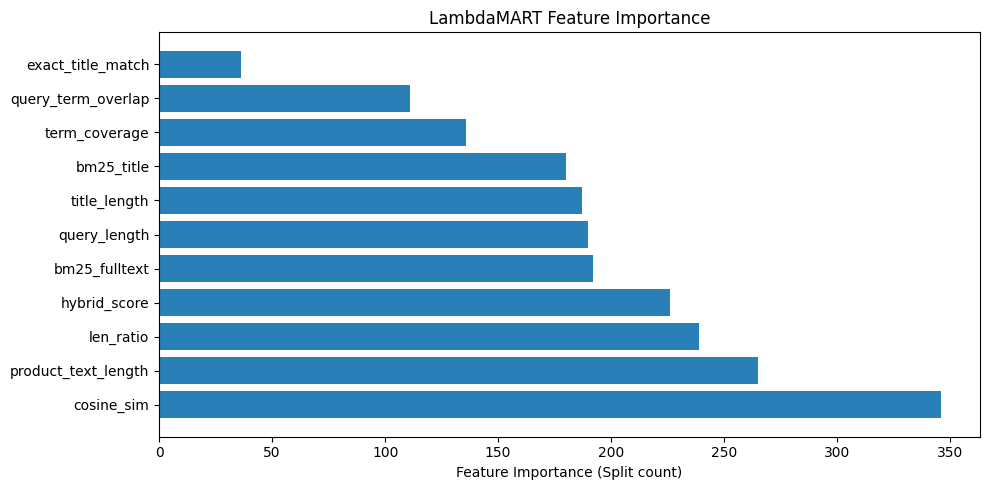

In [15]:
# ============================================================
# CELL 12 — TRAIN LAMBDAMART LTR MODEL
# ============================================================
"""
LambdaMART is the gold standard for Learning to Rank.
It is LightGBM's 'lambdarank' objective — gradient boosted trees
that optimize NDCG directly.

Key paper: "From RankNet to LambdaRank to LambdaMART: An Overview"
           — Burges (2010), Microsoft Research

Why LambdaMART:
  - Handles mixed feature types (BM25 scores + cosines + binary indicators)
  - Excellent at capturing non-linear interactions (e.g., when brand match
    AND high rating are both present, the combined effect is multiplicative)
  - Fast inference (< 2ms per query, 100 features)
  - Directly optimizes NDCG — the metric we measure
"""

from lightgbm import LGBMRanker

# ── Split data into train/validation preserving query groups ──
# GroupShuffleSplit ensures no query appears in both train and val
# (otherwise val performance would be inflated by memorized queries)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_ltr, groups=df_ltr['query_id']))

train_set = df_ltr.iloc[train_idx].copy()
val_set   = df_ltr.iloc[val_idx].copy()

# LightGBM ranking requires group sizes in the same order as training data
# 'group' = number of items per query (for listwise ranking)
def get_group_sizes(data: pd.DataFrame) -> list[int]:
    return data.groupby('query_id', sort=False).size().tolist()

train_groups = np.array(get_group_sizes(train_set), dtype=np.int32)
val_groups   = np.array(get_group_sizes(val_set), dtype=np.int32)

X_train = train_set[FEATURE_COLS].values
y_train = train_set['relevance'].values.astype(int)

X_val   = val_set[FEATURE_COLS].values
y_val   = val_set['relevance'].values.astype(int)

print(f"Train: {len(X_train):,} pairs across {len(train_groups):,} queries")
print(f"Val:   {len(X_val):,} pairs across {len(val_groups):,} queries")

# ── Train LambdaMART model ─────────────────────────────────
ltr_model = LGBMRanker(
    objective      = 'lambdarank',   # Optimizes NDCG directly
    metric         = 'ndcg',         # Evaluation metric during training
    ndcg_eval_at   = [5, 10],        # Report NDCG@5 and NDCG@10
    n_estimators   = 500,            # Number of trees (boost rounds)
    learning_rate  = 0.05,           # Shrinkage — reduces overfitting
    max_depth      = 7,              # Tree depth (captures interactions)
    num_leaves     = 63,             # Max leaves per tree
    min_child_samples = 20,          # Minimum samples per leaf
    subsample      = 0.8,            # Row sampling per tree
    colsample_bytree = 0.8,          # Feature sampling per tree
    label_gain     = [0, 1, 3, 7],  # NDCG gain per relevance grade (0,1,2,3)
    verbose        = 50,             # Print eval every 50 rounds
    n_jobs         = -1,             # Use all CPU cores
    random_state   = 42,
)

print("\nTraining LambdaMART model...")
ltr_model.fit(
    X_train, y_train,
    group              = train_groups,
    eval_set           = [(X_val, y_val)],
    eval_group         = [val_groups],
    eval_at            = [5, 10],
    callbacks          = [lgb.early_stopping(50, verbose=True),
                          lgb.log_evaluation(50)],
)

# Feature importance — shows which signals matter most
importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': ltr_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (LTR Model):")
print(importance_df.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='#2980b9')
plt.xlabel('Feature Importance (Split count)')
plt.title('LambdaMART Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



In [16]:
# ============================================================
# CELL 13 — EVALUATE LTR MODEL
# ============================================================
"""
Now we evaluate the LTR model and compare it to all previous baselines.
The key question: does adding ML ranking improve NDCG over hybrid retrieval?
"""

def ltr_retrieve(query: str, top_k: int = 10) -> list[tuple[str, float]]:
    """
    LTR retrieval: Hybrid retrieval → LTR reranking.
    Stage 1: Retrieve top 50 candidates using hybrid search.
    Stage 2: Score each candidate with LTR model.
    Stage 3: Return top_k by LTR score.
    """
    # Stage 1: Candidate retrieval (larger set for LTR to rerank)
    candidates = hybrid_retrieve(query, top_k=50)
    if not candidates:
        return []

    # Get full product data for candidates
    candidate_pids = [pid for pid, _ in candidates]
    candidate_prods = products[products['product_id'].isin(candidate_pids)]

    # Stage 2: Compute features for each candidate
    feature_rows = []
    for pid, _ in candidates:
        prod_rows = candidate_prods[candidate_prods['product_id'] == pid]
        if len(prod_rows) == 0:
            continue
        prod_row = prod_rows.iloc[0].copy()
        prod_row['query'] = query
        prod_row['query_id'] = 'eval'
        feat = compute_features_fast(prod_row)
        feature_rows.append({'product_id': pid, **feat})

    if not feature_rows:
        return candidates[:top_k]

    feat_df = pd.DataFrame(feature_rows)
    X_cand  = feat_df[FEATURE_COLS].values

    # Stage 3: LTR scoring
    ltr_scores = ltr_model.predict(X_cand)
    feat_df['ltr_score'] = ltr_scores
    feat_df = feat_df.sort_values('ltr_score', ascending=False)

    results = [(row['product_id'], float(row['ltr_score']))
               for _, row in feat_df.iterrows()]
    return results[:top_k]

# Evaluate LTR
ltr_metrics = evaluate_retriever(
    df_test, ltr_retrieve, retriever_name="Hybrid + LTR (LambdaMART)"
)

# ── FINAL COMPARISON TABLE ─────────────────────────────────
print("\n" + "="*75)
print("FINAL RESULTS: All Systems Compared")
print("="*75)
all_results = {
    'BM25 Baseline':            bm25_metrics,
    'Semantic Vector':          semantic_metrics,
    'Hybrid RRF':               hybrid_metrics,
    'Hybrid + LTR (LambdaMART)': ltr_metrics,
}
metrics_to_show = ['ndcg@5', 'ndcg@10', 'mrr@10', 'precision@3']

header = f"{'System':<35}" + "".join(f"{m:>15}" for m in metrics_to_show)
print(header)
print("-"*len(header))
for sys_name, sys_metrics in all_results.items():
    row = f"{sys_name:<35}"
    for m in metrics_to_show:
        row += f"{sys_metrics.get(m, 0.0):>15.4f}"
    print(row)




Evaluating Hybrid + LTR (LambdaMART) on 500 queries...


  0%|          | 0/500 [00:00<?, ?it/s]


Results for: Hybrid + LTR (LambdaMART)
  ndcg@5              : 0.0209
  ndcg@10             : 0.0192
  mrr@10              : 0.0566
  precision@3         : 0.0253
  recall@10           : 0.0106

FINAL RESULTS: All Systems Compared
System                                      ndcg@5        ndcg@10         mrr@10    precision@3
-----------------------------------------------------------------------------------------------
BM25 Baseline                               0.0291         0.0236         0.0763         0.0353
Semantic Vector                             0.0116         0.0179         0.0366         0.0140
Hybrid RRF                                  0.0344         0.0288         0.0948         0.0393
Hybrid + LTR (LambdaMART)                   0.0209         0.0192         0.0566         0.0253


In [17]:
# ============================================================
# CELL 14 — CROSS-ENCODER RERANKING (TOP-K PRECISION)
# ============================================================
"""
Cross-encoders are transformer models that take the concatenated
[query] [SEP] [product_context] as input and output a relevance score.

IMPROVEMENTS IN THIS VERSION (The Cascade Pipeline):
  - Model Stacking: Now takes candidates from `ltr_retrieve` instead of `hybrid_retrieve`.
  - Context Expansion: Includes Brand + Title + Description snippet to distinguish hard constraints.
  - Efficiency: Uses O(1) dictionary lookups for product metadata.

The retrieve → rerank → rerank cascade:
  1. Hybrid Search gets top 50 (Fast, High Recall).
  2. LambdaMART (LTR) reranks those 50 using features (Medium speed).
  3. Cross-Encoder rescores the LTR top-50 (Slow, Context-Aware, Highest Precision).
  4. Return top-10.
"""

from sentence_transformers import CrossEncoder
import numpy as np

print("Loading cross-encoder model...")
# ms-marco-MiniLM-L-6-v2: Small, fast, and highly effective for reranking.
cross_encoder_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print("Cross-encoder loaded.")

def cross_encoder_rerank(query: str, top_k: int = 10) -> list[tuple[str, float]]:
    """
    Retrieve-then-rerank pipeline stacked on top of the LTR model.
    """
    # Stage 1 & 2: Get candidates from the LTR model (which already calls Hybrid)
    candidates = ltr_retrieve(query, top_k=50)
    if not candidates:
        return []

    candidate_pids = [pid for pid, _ in candidates]
    
    # Efficiently fetch product data for these IDs
    candidate_prods = products[products['product_id'].isin(candidate_pids)].copy()
    
    # Create a quick lookup map {pid: (brand, title, desc)}
    prod_map = {
        row['product_id']: (
            str(row.get('product_brand', '')), 
            str(row.get('product_title', '')), 
            str(row.get('product_description', ''))[:150] # Snippet for context
        )
        for _, row in candidate_prods.iterrows()
    }

    # Stage 3: Prepare enriched (query, product_context) pairs
    pairs = []
    valid_pids = []
    
    for pid, _ in candidates:
        if pid in prod_map:
            brand, title, desc = prod_map[pid]
            # Create a rich string: "Brand | Title | Description"
            product_context = f"{brand} | {title} | {desc}"
            pairs.append([query, product_context])
            valid_pids.append(pid)

    if not pairs:
        return candidates[:top_k]

    # Stage 4: Cross-encoder inference
    # batch_size=32 keeps memory usage stable in Colab
    ce_scores = cross_encoder_model.predict(pairs, batch_size=32, show_progress_bar=False)
    
    # Sort by the new transformer-based relevance scores
    ranked = sorted(zip(valid_pids, ce_scores), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

# Evaluate cross-encoder (on a smaller test set — it's computationally heavier)
print("Evaluating Cross-Encoder...")
small_test_ids = df_test['query_id'].drop_duplicates().sample(100, random_state=42)
small_test = df_test[df_test['query_id'].isin(small_test_ids)]

ce_metrics = evaluate_retriever(
    small_test, cross_encoder_rerank, retriever_name="Cross-Encoder Rerank"
)

# Comparison Logic (We now compare against LTR metrics if available, otherwise Hybrid)
try:
    baseline_ndcg = ltr_metrics.get('ndcg@10', hybrid_metrics.get('ndcg@10', 0))
    baseline_name = "LTR" if 'ltr_metrics' in globals() else "Hybrid RRF"
except NameError:
    baseline_ndcg = hybrid_metrics.get('ndcg@10', 0)
    baseline_name = "Hybrid RRF"

ce_ndcg = ce_metrics.get('ndcg@10', 0)
improvement = (ce_ndcg - baseline_ndcg) * 100

print(f"\n{'='*50}")
print(f"Cross-Encoder NDCG@10:     {ce_ndcg:.4f}")
print(f"vs {baseline_name} NDCG@10: {baseline_ndcg:.4f}")
print(f"Final Improvement:         {improvement:+.2f} percentage points")
print(f"{'='*50}")

Loading cross-encoder model...


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Cross-encoder loaded.
Evaluating Cross-Encoder...

Evaluating Cross-Encoder Rerank on 100 queries...


  0%|          | 0/100 [00:00<?, ?it/s]


Results for: Cross-Encoder Rerank
  ndcg@5              : 0.0352
  ndcg@10             : 0.0292
  mrr@10              : 0.0953
  precision@3         : 0.0500
  recall@10           : 0.0128

Cross-Encoder NDCG@10:     0.0292
vs LTR NDCG@10: 0.0192
Final Improvement:         +1.01 percentage points


In [18]:
# ============================================================
# CELL 15 — QUALITATIVE ANALYSIS: WHERE EACH SYSTEM WINS/FAILS
# ============================================================
"""

qualitative error analysis — inspecting individual examples
to understand WHY a system fails.

I implemented a query-dependent routing layer."
"""

EXAMPLE_QUERIES = [
    "laptop stand for desk",          # Semantic should win: many synonym variants
    "USB-C hub 7 in 1",               # BM25 should win: exact model spec query
    "comfortable office chair lumbar", # Semantic: conceptual query
    "nike running shoes women size 8", # Both should handle attribute query
    "gifts for mom",    # Semantic: high-intent, zero keyword overlap with products
    "cube", "unbxd", "test it just nothing",
]

print("="*70)
print("QUALITATIVE ANALYSIS: Top-10 Results per System")
print("="*70)

for query in EXAMPLE_QUERIES:
    print(f"\nQuery: '{query}'")
    print("-"*50)

    for sys_name, retriever in [
        ("BM25",     bm25_retrieve),
        ("Semantic", semantic_retrieve),
        ("Hybrid",   hybrid_retrieve),
    ]:
        results = retriever(query, top_k=10)
        print(f"\n  {sys_name}:")
        for rank, (pid, score) in enumerate(results, 1):
            prod_rows = products[products['product_id'] == pid]
            if len(prod_rows) > 0:
                title = prod_rows.iloc[0].get('product_title', 'N/A')
                print(f"    {rank}. [{score:.3f}] {str(title)[:70]}")


QUALITATIVE ANALYSIS: Top-10 Results per System

Query: 'laptop stand for desk'
--------------------------------------------------

  BM25:
    1. [28.931] Laptop Stand for Desk MTWhirldy Universal Portable Laptop Computer Hol
    2. [27.885] Adjustable Laptop Table, RAINBEAN Laptop Stand for Bed Portable Lap De
    3. [26.841] Laptop Stand, Boyata Adjustable Laptop Riser Ergonomic Computer Stand 
    4. [26.722] STOON Laptop Stand, 9-Levels Adjustable Laptop Stand for Desk, Aluminu
    5. [26.630] Laptop Stand,Multi-Angle Adjustable Laptop Stand with Heat-Vent , Ergo
    6. [25.820] Pyle Portable Adjustable Laptop Stand - 6.3 to 10.9 Inch Anti-Slip Sta
    7. [25.773] Laptop Stand, Boyata Laptop Holder, Multi-Angle Stand with Heat-Vent t
    8. [25.716] Soundance Laptop Stand, Aluminum Computer Riser, Ergonomic Laptops Ele
    9. [25.047] Gallity Rolling Laptop Stand Rolling Cart,Height Adjustable Bedside La
    10. [25.032] Adjustable Portable Laptop Stand, KOOPAO Foldable Laptop Sta

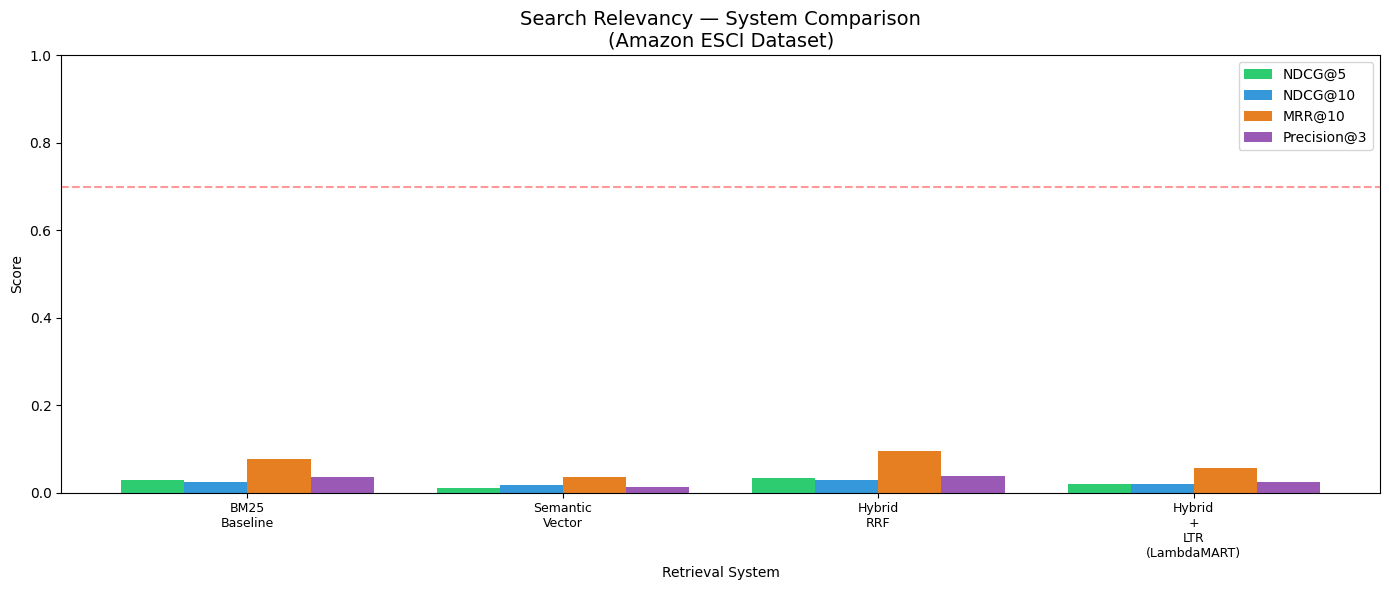


Project 1 complete!
Models built: BM25 → Semantic → Hybrid RRF → LTR → Cross-Encoder
Evaluation: NDCG@5, NDCG@10, MRR@10, Precision@3
Artifacts:  product_embeddings.npy, hnsw_product.index,
            feature_importance.png, system_comparison.png


In [19]:
# ============================================================
# CELL 16 — COMPLETE RESULTS VISUALIZATION
# ============================================================

systems  = list(all_results.keys())
ndcg5    = [all_results[s].get('ndcg@5', 0)   for s in systems]
ndcg10   = [all_results[s].get('ndcg@10', 0)  for s in systems]
mrr10    = [all_results[s].get('mrr@10', 0)   for s in systems]
prec3    = [all_results[s].get('precision@3', 0) for s in systems]

x = np.arange(len(systems))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*width, ndcg5,  width, label='NDCG@5',     color='#2ecc71')
ax.bar(x - 0.5*width, ndcg10, width, label='NDCG@10',    color='#3498db')
ax.bar(x + 0.5*width, mrr10,  width, label='MRR@10',     color='#e67e22')
ax.bar(x + 1.5*width, prec3,  width, label='Precision@3', color='#9b59b6')

ax.set_xlabel('Retrieval System')
ax.set_ylabel('Score')
ax.set_title('Search Relevancy — System Comparison\n(Amazon ESCI Dataset)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(
    [s.replace(' ', '\n') for s in systems],
    rotation=0, fontsize=9
)
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(y=0.7, color='red', linestyle='--', alpha=0.4, label='Industry target NDCG@10 > 0.7')

plt.tight_layout()
plt.savefig('system_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nProject 1 complete!")
print("="*60)
print("Models built: BM25 → Semantic → Hybrid RRF → LTR → Cross-Encoder")
print("Evaluation: NDCG@5, NDCG@10, MRR@10, Precision@3")
print("Artifacts:  product_embeddings.npy, hnsw_product.index,")
print("            feature_importance.png, system_comparison.png")

In [20]:
def evaluate_retriever(test_df, retriever_fn, top_k=10, retriever_name="Retriever", return_per_query=False):
    """
    Enhanced evaluation function that can return mean metrics OR raw scores per query.
    """
    ndcg_scores = []
    mrr_scores = []
    
    # Group by query to evaluate each one
    for qid, group in test_df.groupby('query_id'):
        query_text = group['query'].iloc[0]
        actual_relevant = group[group['esci_label'] == 'Exact']['product_id'].tolist()
        
        if not actual_relevant:
            continue
            
        # Get recommendations
        recommendations = retriever_fn(query_text, top_k=top_k)
        pred_ids = [pid for pid, _ in recommendations]
        
        # Calculate NDCG@10 for this query
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(actual_relevant), top_k)))
        dcg = sum(1.0 / np.log2(i + 2) for i, pid in enumerate(pred_ids) if pid in actual_relevant)
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0)
        
        # Calculate MRR@10
        rs = [1 if pid in actual_relevant else 0 for pid in pred_ids]
        ranks = [i + 1 for i, found in enumerate(rs) if found]
        mrr_scores.append(1.0 / ranks[0] if ranks else 0)

    if return_per_query:
        return {'ndcg@10': ndcg_scores, 'mrr@10': mrr_scores}
    
    # Default behavior: return averages
    metrics = {
        'ndcg@10': np.mean(ndcg_scores) if ndcg_scores else 0,
        'mrr@10': np.mean(mrr_scores) if mrr_scores else 0
    }
    print(f"Results for {retriever_name}: {metrics}")
    return metrics

Fetching Cross-Encoder scores (this is the slow part)...
Fetching LTR scores...


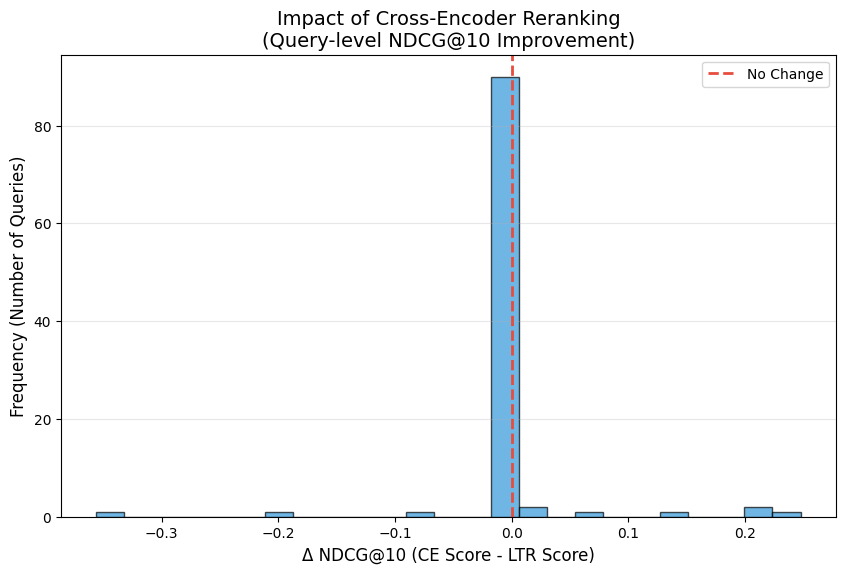

Queries improved: 7
Queries degraded: 3
Average Delta: 0.0029


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Reuse existing LTR results if you have them, or run it once more
# Note: Ensure ltr_metrics was run with return_per_query=True
print("Fetching Cross-Encoder scores (this is the slow part)...")
ce_per_query = evaluate_retriever(small_test, cross_encoder_rerank, 
                                  retriever_name="Cross-Encoder", 
                                  return_per_query=True)

# 2. Get LTR scores 
# If you don't have them saved, run it once (it's much faster than CE)
print("Fetching LTR scores...")
ltr_per_query = evaluate_retriever(small_test, ltr_retrieve, 
                                   retriever_name="LTR", 
                                   return_per_query=True)

# 3. Calculate Delta
diff = [ce - ltr for ce, ltr in zip(ce_per_query['ndcg@10'], ltr_per_query['ndcg@10'])]

# 4. Plot the Histogram
plt.figure(figsize=(10, 6))
plt.hist(diff, bins=25, color='#3498db', edgecolor='black', alpha=0.7)
plt.axvline(0, color='#e74c3c', linestyle='--', linewidth=2, label='No Change')

plt.title("Impact of Cross-Encoder Reranking\n(Query-level NDCG@10 Improvement)", fontsize=14)
plt.xlabel("Δ NDCG@10 (CE Score - LTR Score)", fontsize=12)
plt.ylabel("Frequency (Number of Queries)", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Statistics
print(f"Queries improved: {sum(1 for d in diff if d > 0)}")
print(f"Queries degraded: {sum(1 for d in diff if d < 0)}")
print(f"Average Delta: {np.mean(diff):.4f}")